In [1]:
import ephem, datetime, re
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

planets = pd.DataFrame()
planets['body'] = [ephem.Mercury(),
                  ephem.Venus(),
                  ephem.Mars(),
                  ephem.Jupiter(),
                  ephem.Saturn(),
                  ephem.Uranus(),
                  ephem.Neptune()]
planets['name'] = planets['body'].apply(lambda x: x.name)
planets['color'] = ['r', 'g', 'b', 'k', 'm', 'c' , 'y']  # for plotting later
planets

,body,name,color
0,"<Mercury ""Mercury"" at 0x10ec64050>",Mercury,r
1,"<Venus ""Venus"" at 0x10ec641e0>",Venus,g
2,"<Mars ""Mars"" at 0x10ec64370>",Mars,b
3,"<ephem.Jupiter ""Jupiter"" at 0x10e7c5530>",Jupiter,k
4,"<ephem.Saturn ""Saturn"" at 0x10e7c71b0>",Saturn,m
5,"<Uranus ""Uranus"" at 0x10ec64500>",Uranus,c
6,"<Neptune ""Neptune"" at 0x10ec64690>",Neptune,y


In [2]:
# parse data from https://promenade.imcce.fr/en/pages6/887.html
prom = pd.DataFrame(columns=['type', 'planet', 'date', 'time', 'elong', 'dec'])
with open('../data/greatest_elongations.txt') as fp:
    lines = fp.read().splitlines()
    for line in lines:
        s_head = re.search(r'Dates of the .* of (.*) from', line)
        if s_head==None:
            s_date = re.search(r' (\d{4} [A-Z][a-z]{2} .\d) ', line)
            if s_date!=None:
                idx = len(prom)
                prom.loc[idx, 'type'] = typ
                prom.loc[idx, 'planet'] = planet
                prom.loc[idx, 'date'] = s_date.group(1)
            if typ=='largest elongation':
                s_elong = re.search(r' (\d{2}\.\d..)', line)
                if s_elong!=None:
                    prom.loc[idx, 'elong']  = s_elong.group(1)
            elif typ=='opposition':
                s_time = re.search(r' (\d{2}:\d{2}) ', line)
                if s_time!=None:
                    prom.loc[idx, 'time'] = s_time.group(1)
                s_dec = re.search(r'   (.\d{2}..\d{2}.)', line)
                if s_dec!=None:
                    prom.loc[idx, 'dec']  = s_dec.group(1)
        else:
            planet = s_head.group(1)
            typ = re.search(r'Dates of the (.*) of', line).group(1)[:-1]
            typ = typ.replace('largerst', 'largest')
            year0 = re.search(r'Dates of the .* of .* from (.*) to', line).group(1)
            year1 = re.search(r'Dates of the .* of .* from .* to (.*).', line).group(1)
            print(planet, typ, year0, year1)

prom['date'] = pd.to_datetime(prom['date'])
assert prom.loc[prom['dec'].isna(), 'type'].unique() == 'largest elongation'
assert prom.loc[prom['time'].isna(), 'type'].unique() == 'largest elongation'
assert prom.loc[prom['elong'].isna(), 'type'].unique() == 'opposition'
assert prom.loc[prom['type']=='largest elongation', 'dec'].isna().all()
assert prom.loc[prom['type']=='largest elongation', 'time'].isna().all()
assert prom.loc[prom['type']=='opposition', 'elong'].isna().all()
assert prom.loc[prom['type']=='largest elongation', 'date'].min().year >= 2014
assert prom.loc[prom['type']=='largest elongation', 'date'].max().year <= 2029
assert prom.loc[prom['type']=='opposition', 'date'].min().year >= 1950
assert prom.loc[prom['type']=='opposition', 'date'].max().year <= 2099
prom

Mercury largest elongation 2014 2029
Venus largest elongation 2014 2029
Mars opposition 1950 2099
Jupiter opposition 1950 2099
Saturn opposition 1950 2099
Uranus opposition 1950 2099
Neptune opposition 1950 2099


,type,planet,date,time,elong,dec
0,largest elongation,Mercury,2014-01-31,NaN,18.4°E,NaN
1,largest elongation,Mercury,2014-03-14,NaN,27.6°W,NaN
2,largest elongation,Mercury,2014-05-25,NaN,22.7°E,NaN
3,largest elongation,Mercury,2014-07-12,NaN,20.9°W,NaN
4,largest elongation,Mercury,2014-09-21,NaN,26.4°E,NaN
...,...,...,...,...,...,...
766,opposition,Neptune,2095-02-23,08:03,NaN,+10° 19'
767,opposition,Neptune,2096-02-25,18:09,NaN,+09° 34'
768,opposition,Neptune,2097-02-27,04:31,NaN,+08° 48'
769,opposition,Neptune,2098-03-01,14:56,NaN,+08° 01'


In [3]:
def ew2pm(x):
# convert E-or-W notation in elong to plus/minus (see the two columns elong and elong_ew2pm)
    x = str(x)
    if x[-1]=='E':
        return float(x[:-2])
    elif x[-1]=='W':
        return -float(x[:-2])
prom['elong_ew2pm'] = prom.apply(lambda x: ew2pm(x.elong), axis=1)
prom

,type,planet,date,time,elong,dec,elong_ew2pm
0,largest elongation,Mercury,2014-01-31,NaN,18.4°E,NaN,18.4
1,largest elongation,Mercury,2014-03-14,NaN,27.6°W,NaN,-27.6
2,largest elongation,Mercury,2014-05-25,NaN,22.7°E,NaN,22.7
3,largest elongation,Mercury,2014-07-12,NaN,20.9°W,NaN,-20.9
4,largest elongation,Mercury,2014-09-21,NaN,26.4°E,NaN,26.4
...,...,...,...,...,...,...,...
766,opposition,Neptune,2095-02-23,08:03,NaN,+10° 19',NaN
767,opposition,Neptune,2096-02-25,18:09,NaN,+09° 34',NaN
768,opposition,Neptune,2097-02-27,04:31,NaN,+08° 48',NaN
769,opposition,Neptune,2098-03-01,14:56,NaN,+08° 01',NaN


In [4]:
# for each row of data in prom, lookup elongation from ephem
def grab_elong(x):
    planet = planets.loc[planets['name']==x.planet, 'body'].values[0]
    planet.compute(x.date)
    return np.rad2deg(planet.elong)
prom['elong_lookup'] = prom.apply(lambda x: grab_elong(x), axis=1)
prom

,type,planet,date,time,elong,dec,elong_ew2pm,elong_lookup
0,largest elongation,Mercury,2014-01-31,NaN,18.4°E,NaN,18.4,18.359991
1,largest elongation,Mercury,2014-03-14,NaN,27.6°W,NaN,-27.6,-27.551643
2,largest elongation,Mercury,2014-05-25,NaN,22.7°E,NaN,22.7,22.677723
3,largest elongation,Mercury,2014-07-12,NaN,20.9°W,NaN,-20.9,-20.890789
4,largest elongation,Mercury,2014-09-21,NaN,26.4°E,NaN,26.4,26.380985
...,...,...,...,...,...,...,...,...
766,opposition,Neptune,2095-02-23,08:03,NaN,+10° 19',NaN,-179.235474
767,opposition,Neptune,2096-02-25,18:09,NaN,+09° 34',NaN,-178.923828
768,opposition,Neptune,2097-02-27,04:31,NaN,+08° 48',NaN,-179.166489
769,opposition,Neptune,2098-03-01,14:56,NaN,+08° 01',NaN,-178.921173


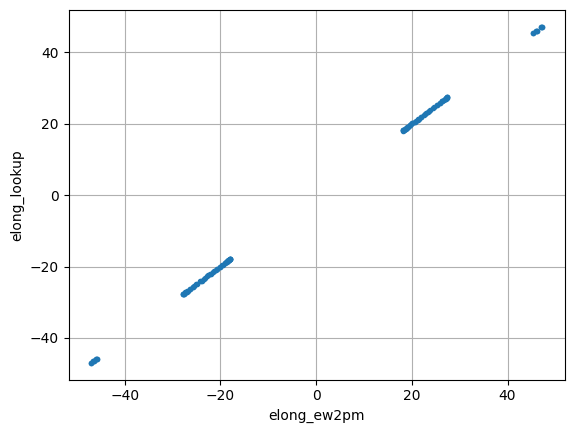

In [5]:
tis, tat = prom['elong_ew2pm'], prom['elong_lookup']
# find disagreement betwen tis and tat (for "this" and "that")
# we start with an eyeball inspection
plt.plot(prom['elong_ew2pm'], prom['elong_lookup'], '.')
plt.xlabel('elong_ew2pm'); plt.ylabel('elong_lookup')
plt.grid(True)
# looks good: points fall along a diagonal line x=y

In [6]:
# take disagreement as the ratio of difference (between the two) to the average (of the two)
disagreement = 2*(tis-tat)/(tis+tat) 
disagreement.describe()
# disagreement is small, as expected, so we are good
# can't expect anything better, as the original value (elong) was given to one decimal place only

count    121.000000
mean       0.000567
std        0.001340
min       -0.002408
25%       -0.000462
50%        0.000528
75%        0.001513
max        0.003761
dtype: float64

In [7]:
# elongation at opposition should always be around -180 or 180
elong_at_opposition = prom.loc[prom['type']=='opposition', 'elong_lookup']
mmin = elong_at_opposition.min()
mmax = elong_at_opposition.max()
assert np.allclose(mmin, -180, rtol=1e-3)
assert np.allclose(mmax, 180, rtol=1e-2)
elong_at_opposition.describe()
# looks good

count    650.000000
mean    -176.260900
std       27.925673
min     -179.923386
25%     -179.165100
50%     -178.706879
75%     -178.138222
max      179.229126
Name: elong_lookup, dtype: float64

In [8]:
# sanity-check textbook values
prom.loc[prom['type']=='largest elongation'].groupby('planet')['elong_ew2pm'].min()

planet
Mercury   -27.8
Venus     -47.0
Name: elong_ew2pm, dtype: float64

In [9]:
prom.loc[prom['type']=='largest elongation'].groupby('planet')['elong_ew2pm'].max()

planet
Mercury    27.4
Venus      47.2
Name: elong_ew2pm, dtype: float64

In [10]:
# sweep ephem through 5 years and from the values, find the min-max range for each planet
sweep = pd.DataFrame(columns=['planet', 'date', 'elong_rad'])
for idx, dat in planets.iterrows():
    mytime = datetime.datetime(2026, 1, 1, 0, 0)
    dat['body'].compute(mytime)
    elong0 = dat['body'].elong
    rmember = elong0
    for _ in range(200):
        mytime += pd.DateOffset(weeks=1)
        dat['body'].compute(mytime)
        elong = dat['body'].elong
        sweep.loc[len(sweep)] = [dat['name'], mytime, elong]
#       if rmember<elong0 and elong>elong0:
#           break
        rmember = elong
sweep['elong_deg'] = sweep['elong_rad'].apply(lambda x: np.rad2deg(x))
sweep

,planet,date,elong_rad,elong_deg
0,Mercury,2026-01-08,-0.145216,-8.320253
1,Mercury,2026-01-15,-0.079666,-4.564548
2,Mercury,2026-01-22,0.036179,2.072917
3,Mercury,2026-01-29,0.096082,5.505095
4,Mercury,2026-02-05,0.183147,10.493531
...,...,...,...,...
1395,Neptune,2029-10-04,3.105378,177.925064
1396,Neptune,2029-10-11,2.991006,171.372025
1397,Neptune,2029-10-18,2.867779,164.311661
1398,Neptune,2029-10-25,2.743577,157.195374


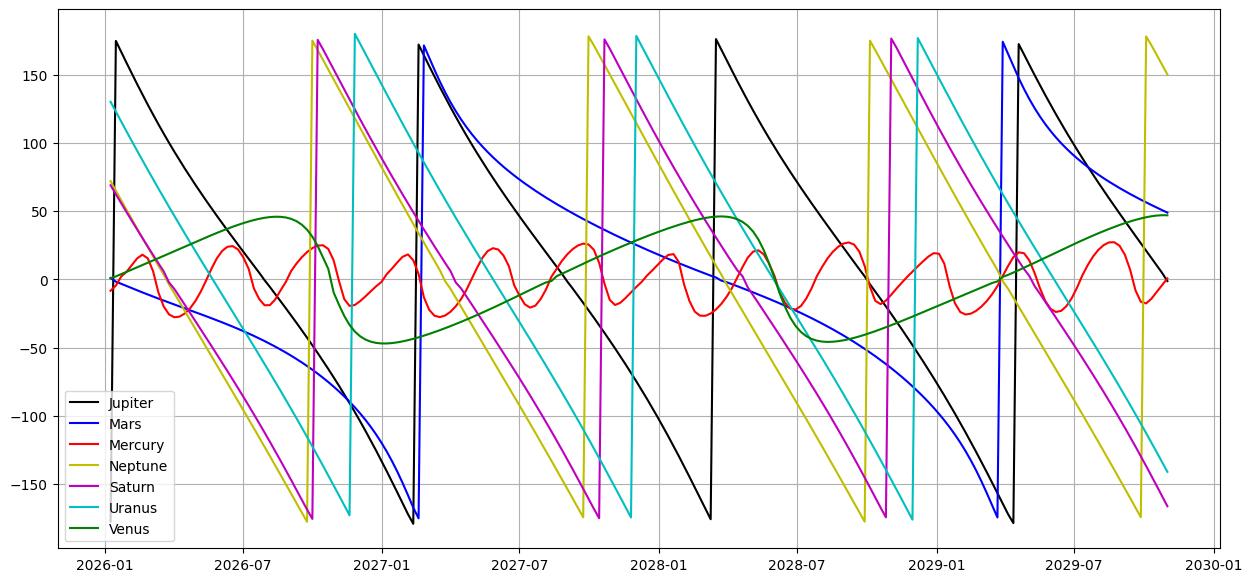

In [12]:
plt.figure(figsize=(15,7))
for planet, dat in sweep.groupby('planet'):
    plt.plot(dat['date'], dat['elong_deg'], label=planet, color=planets.loc[planets['name']==planet, 'color'].values[0])
plt.legend(); plt.grid()

In [13]:
mmin = sweep.groupby('planet')['elong_deg'].min()
mmin.name = 'elong_min'
mmin

planet
Jupiter   -178.945847
Mars      -174.963043
Mercury    -27.729191
Neptune   -177.490036
Saturn    -175.390732
Uranus    -175.943848
Venus      -46.917679
Name: elong_min, dtype: float64

In [14]:
mmax = sweep.groupby('planet')['elong_deg'].max()
mmax.name = 'elong_max'
mmax

planet
Jupiter    175.923065
Mars       173.992599
Mercury     27.189339
Neptune    177.954865
Saturn     176.343689
Uranus     179.836441
Venus       46.996708
Name: elong_max, dtype: float64

In [15]:
# merge mmin and mmax into dataframe 'planets'
planets = pd.merge(planets, mmin, left_on='name', right_index=True)
planets = pd.merge(planets, mmax, left_on='name', right_index=True)
planets

,body,name,color,elong_min,elong_max
0,"<Mercury ""Mercury"" at 0x10ec64050>",Mercury,r,-27.729191,27.189339
1,"<Venus ""Venus"" at 0x10ec641e0>",Venus,g,-46.917679,46.996708
2,"<Mars ""Mars"" at 0x10ec64370>",Mars,b,-174.963043,173.992599
3,"<ephem.Jupiter ""Jupiter"" at 0x10e7c5530>",Jupiter,k,-178.945847,175.923065
4,"<ephem.Saturn ""Saturn"" at 0x10e7c71b0>",Saturn,m,-175.390732,176.343689
5,"<Uranus ""Uranus"" at 0x10ec64500>",Uranus,c,-175.943848,179.836441
6,"<Neptune ""Neptune"" at 0x10ec64690>",Neptune,y,-177.490036,177.954865
